# ADAM optimizer

In [1]:
# needed imports
import matplotlib.pyplot as plt
import numpy as np

from ADAM import ADAM
from model import Model
from nodes import CrossEntropyLoss, KBinaryCELoss
from optimizer import Optimizer
from scaler import Scaler
from utils import load_batch, calculate_mean_grad_difference
from torch_gradient_computations import ComputeGradsWithTorch

In [2]:
# Load all data batches
X_test, Y_test, y_test = load_batch("test_batch")

X, Y, y = load_batch("data_batch_1")
for i in range(2,6):
    X_temp, Y_temp, y_temp = load_batch(f"data_batch_{i}")
    X = np.concatenate((X, X_temp), axis=1)
    Y = np.concatenate((Y, Y_temp), axis=1)
    y = np.concatenate((y, y_temp))
# split into training and validation sets
X_train = X[:, :45000]
y_train = y[:45000]
X_val = X[:, 45000:]
y_val = y[45000:]
# scale data
scaler = Scaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment2/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [3]:
model = Model(32*32*3, 200, 10)
optimizer = ADAM(model, CrossEntropyLoss(), lr=1e-3, reg=1e-4, vertical_flip_prob=0.5)

In [50]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=50, print_every=5)

Epoch 5/40 - Train Loss: 1.3537, Val Loss: 1.4769, Train Acc: 0.5278, Val Acc: 0.4830
Epoch 10/40 - Train Loss: 1.2676, Val Loss: 1.4189, Train Acc: 0.5526, Val Acc: 0.5128
Epoch 15/40 - Train Loss: 1.2499, Val Loss: 1.4152, Train Acc: 0.5648, Val Acc: 0.5122
Epoch 20/40 - Train Loss: 1.2552, Val Loss: 1.4538, Train Acc: 0.5610, Val Acc: 0.5048
Epoch 25/40 - Train Loss: 1.1637, Val Loss: 1.3970, Train Acc: 0.5915, Val Acc: 0.5220
Epoch 30/40 - Train Loss: 1.1456, Val Loss: 1.3807, Train Acc: 0.6003, Val Acc: 0.5390
Epoch 35/40 - Train Loss: 1.1135, Val Loss: 1.3734, Train Acc: 0.6122, Val Acc: 0.5404
Epoch 40/40 - Train Loss: 1.1174, Val Loss: 1.3827, Train Acc: 0.6085, Val Acc: 0.5308


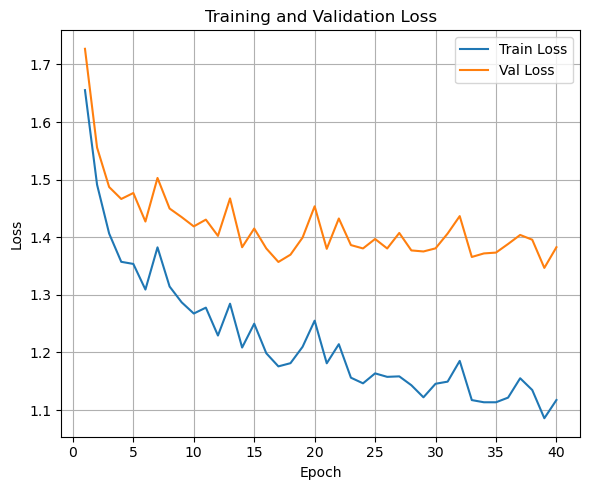

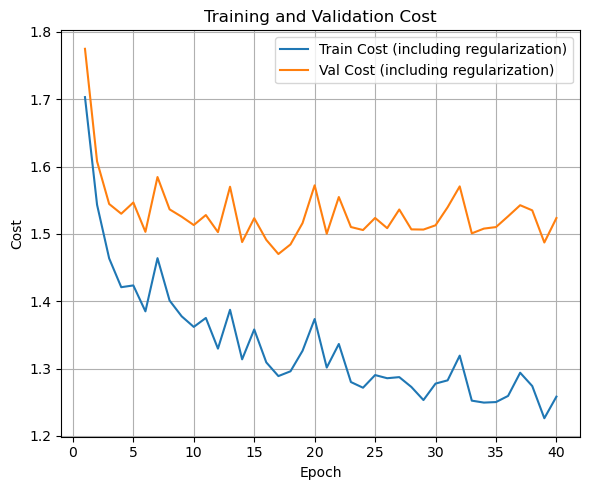

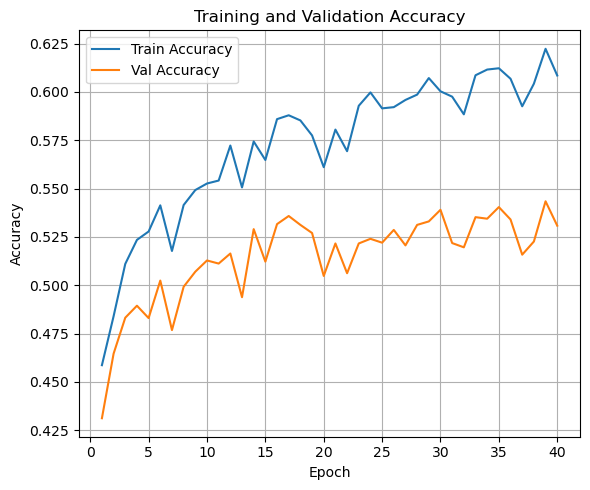

In [51]:
optimizer.plot_training_progress()

In [52]:
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.5214


# Optimizing the performance
## Number of hidden nodes

In [3]:
results = {}
n_batch = 100
N = X_train.shape[1]
n_s = int(2 * np.floor(N / n_batch))

In [10]:
n_hidden_nodes = [50, 100, 200, 400]
reg_values = [0.0013, 0.006, 0.006, 0.006]
for i in range(len(n_hidden_nodes)):
    print(f"Training model with {n_hidden_nodes[i]} hidden nodes and reg={reg_values[i]}")
    model = Model(32*32*3, n_hidden_nodes[i], 10)
    optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=reg_values[i], vertical_flip_prob=0)
    optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=n_s, n_cycles=3, batch_size=n_batch, print_every=0)
    val_acc = optimizer.val_acc_history[-1]
    test_acc = optimizer.compute_accuracy(X_test, y_test)
    results[(n_hidden_nodes[i], reg_values[i])] = (val_acc, test_acc)
    print(f"Validation accuracy: {val_acc:.4f}, Test accuracy: {test_acc:.4f}")

Training model with 50 hidden nodes and reg=0.006
Validation accuracy: 0.5222, Test accuracy: 0.5165
Training model with 100 hidden nodes and reg=0.006
Validation accuracy: 0.5458, Test accuracy: 0.5349
Training model with 200 hidden nodes and reg=0.006
Validation accuracy: 0.5562, Test accuracy: 0.5477
Training model with 400 hidden nodes and reg=0.006
Validation accuracy: 0.5624, Test accuracy: 0.5518


Max test accuracy:
- 400 hidden nodes, reg = 0.006 -> 0.5520

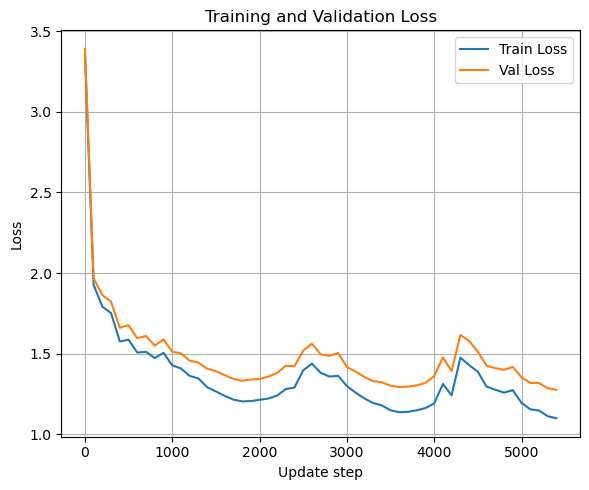

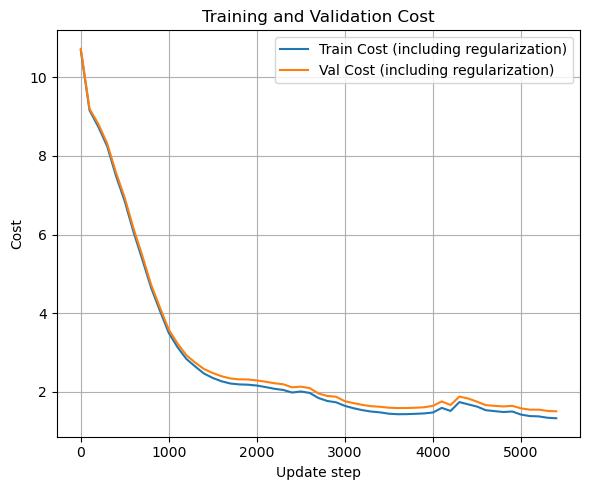

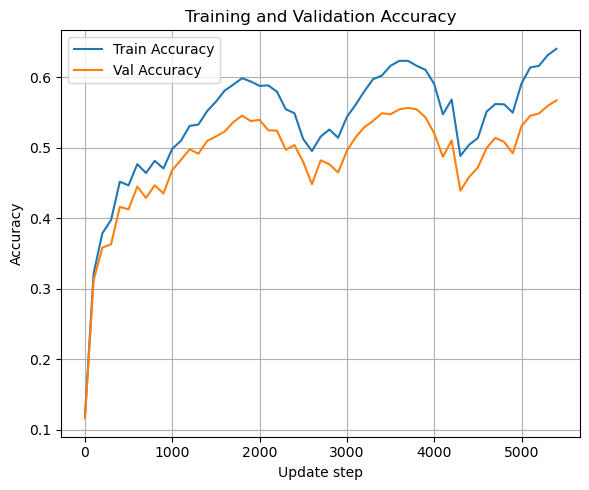

In [7]:
model = Model(32*32*3, 600, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=0.006)
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=n_s, n_cycles=3, batch_size=n_batch, print_every=0)
val_acc = optimizer.val_acc_history[-1]
test_acc = optimizer.compute_accuracy(X_test, y_test)
optimizer.plot_cyclical_lr_training_progress()

In [8]:
print("validation accuracy: ", val_acc)
print("test accuracy: ", test_acc)

validation accuracy:  0.5672
test accuracy:  0.5495


## Translation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9092068620600717..2.0407826090195895].


(3072, 4)
(3072,)


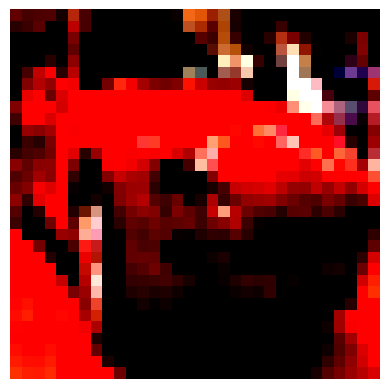

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.920172159417458..1.8676907021182043].


(3072,)


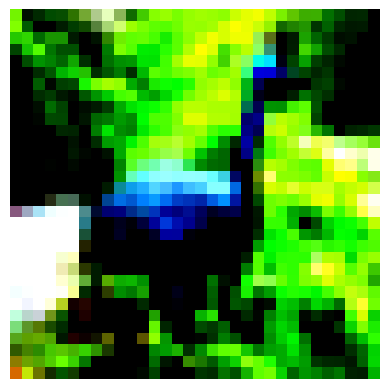

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8501726022119718..2.323411057973081].


(3072,)


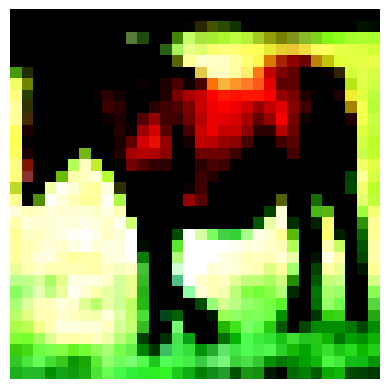

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9092068620600717..2.0377564935505497].


(3072,)


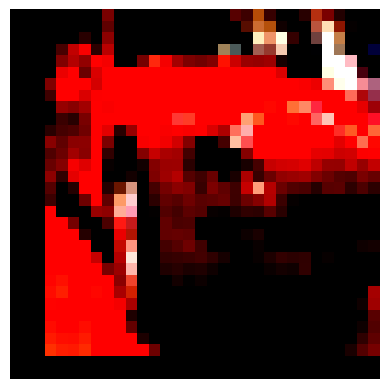

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.920172159417458..1.8676907021182043].


(3072,)


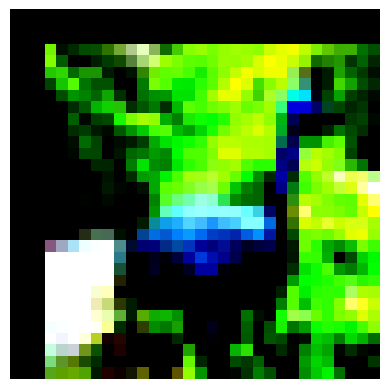

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8501726022119718..2.323411057973081].


(3072,)


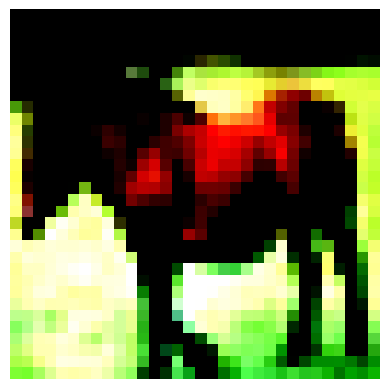

In [3]:
model = Model(32*32*3, 400, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=1e-4, vertical_flip_prob=0.5)
# test the horizontal flipping:
xx = X_train[:,5:9]
print(xx.shape)
xx_flipped = optimizer.translate_batch(xx)
for i in range(3):
    x = xx[:, i]
    print(x.shape)
    x = x.reshape((32, 32, 3), order='F')
    x = np.transpose(x, (1, 0, 2))
    plt.imshow(x)
    plt.axis('off')
    plt.pause(0.1)
for i in range(3):
    x = xx_flipped[:, i]
    print(x.shape)
    x = x.reshape((32, 32, 3), order='F')
    x = np.transpose(x, (1, 0, 2))
    plt.imshow(x)
    plt.axis('off')
    plt.pause(0.1)

### Translation only

In [7]:
model = Model(32*32*3, 400, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=0.001, vertical_flip_prob=0, do_batch_translation=True)
n_batch = 100
N = X_train.shape[1]
n_s = int(2 * np.floor(N / n_batch))
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=n_s, n_cycles=3, batch_size=n_batch, print_every=500)

Update step 500 - Train Loss: 1.7540, Val Loss: 1.7600, Train Acc: 0.3933, Val Acc: 0.3978, LR: 0.055449
Update step 1000 - Train Loss: 1.7014, Val Loss: 1.7143, Train Acc: 0.4137, Val Acc: 0.4112, LR: 0.089001
Update step 1500 - Train Loss: 1.4200, Val Loss: 1.4347, Train Acc: 0.5006, Val Acc: 0.5008, LR: 0.033451
Update step 2000 - Train Loss: 1.3613, Val Loss: 1.3871, Train Acc: 0.5241, Val Acc: 0.5202, LR: 0.022119
Update step 2500 - Train Loss: 1.4436, Val Loss: 1.4738, Train Acc: 0.4988, Val Acc: 0.4914, LR: 0.077669
Update step 3000 - Train Loss: 1.4189, Val Loss: 1.4322, Train Acc: 0.5026, Val Acc: 0.5018, LR: 0.066781
Update step 3500 - Train Loss: 1.2789, Val Loss: 1.3118, Train Acc: 0.5543, Val Acc: 0.5446, LR: 0.011231
Update step 4000 - Train Loss: 1.3587, Val Loss: 1.3939, Train Acc: 0.5219, Val Acc: 0.5146, LR: 0.044339
Update step 4500 - Train Loss: 1.4938, Val Loss: 1.5191, Train Acc: 0.4776, Val Acc: 0.4752, LR: 0.099889
Update step 5000 - Train Loss: 1.3158, Val Loss

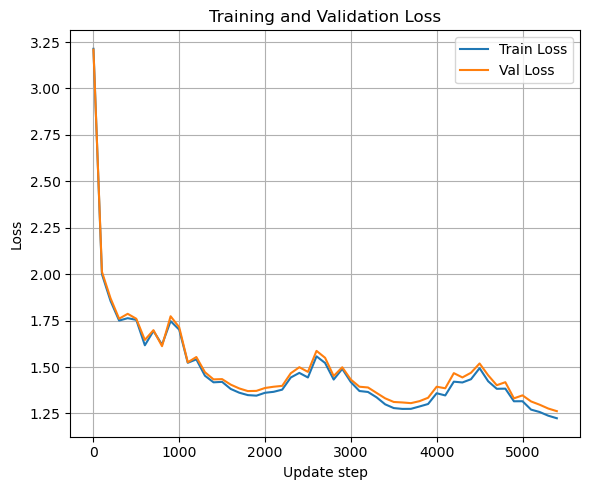

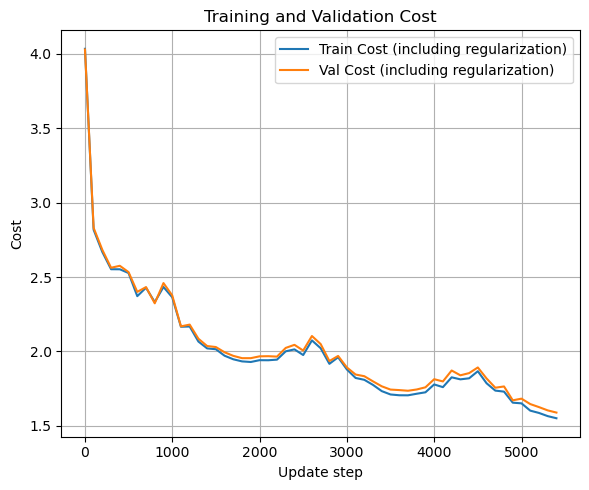

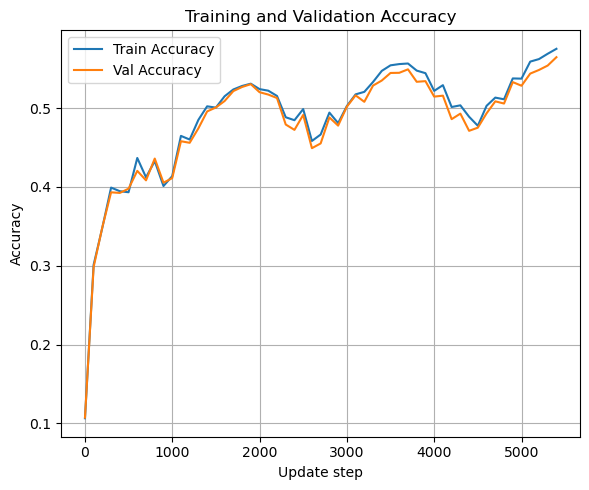

In [8]:
optimizer.plot_cyclical_lr_training_progress()

In [9]:
val_acc = optimizer.compute_accuracy(X_val, y_val)
test_acc = optimizer.compute_accuracy(X_test, y_test)
print("validation accuracy: ", val_acc)
print("test accuracy: ", test_acc)

validation accuracy:  0.5646
test accuracy:  0.5521


best accuracy: 0.5610

## Rotation only

In [12]:
model = Model(32*32*3, 400, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=0.001, vertical_flip_prob=0.5, do_batch_translation=False)
n_batch = 100
N = X_train.shape[1]
n_s = int(2 * np.floor(N / n_batch))
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=n_s, n_cycles=3, batch_size=n_batch, print_every=500)

Update step 500 - Train Loss: 1.6405, Val Loss: 1.6948, Train Acc: 0.4347, Val Acc: 0.4154, LR: 0.055449
Update step 1000 - Train Loss: 1.5161, Val Loss: 1.5742, Train Acc: 0.4694, Val Acc: 0.4536, LR: 0.089001
Update step 1500 - Train Loss: 1.2721, Val Loss: 1.3555, Train Acc: 0.5591, Val Acc: 0.5276, LR: 0.033451
Update step 2000 - Train Loss: 1.2327, Val Loss: 1.3376, Train Acc: 0.5740, Val Acc: 0.5366, LR: 0.022119
Update step 2500 - Train Loss: 1.3504, Val Loss: 1.4606, Train Acc: 0.5315, Val Acc: 0.5042, LR: 0.077669
Update step 3000 - Train Loss: 1.3178, Val Loss: 1.4329, Train Acc: 0.5415, Val Acc: 0.4976, LR: 0.066781
Update step 3500 - Train Loss: 1.1058, Val Loss: 1.2527, Train Acc: 0.6211, Val Acc: 0.5654, LR: 0.011231
Update step 4000 - Train Loss: 1.1417, Val Loss: 1.3079, Train Acc: 0.6041, Val Acc: 0.5448, LR: 0.044339
Update step 4500 - Train Loss: 1.3118, Val Loss: 1.4560, Train Acc: 0.5417, Val Acc: 0.4948, LR: 0.099889
Update step 5000 - Train Loss: 1.1377, Val Loss

In [13]:
val_acc = optimizer.compute_accuracy(X_val, y_val)
test_acc = optimizer.compute_accuracy(X_test, y_test)
print("validation accuracy: ", val_acc)
print("test accuracy: ", test_acc)

validation accuracy:  0.5778
test accuracy:  0.5654


## Translation and rotation


In [14]:
model = Model(32*32*3, 400, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=0, vertical_flip_prob=0.5, do_batch_translation=True)
n_batch = 100
N = X_train.shape[1]
n_s = int(2 * np.floor(N / n_batch))
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=n_s, n_cycles=3, batch_size=n_batch, print_every=500)

Update step 500 - Train Loss: 1.6879, Val Loss: 1.6844, Train Acc: 0.4144, Val Acc: 0.4176, LR: 0.055449
Update step 1000 - Train Loss: 1.5667, Val Loss: 1.5539, Train Acc: 0.4460, Val Acc: 0.4518, LR: 0.089001
Update step 1500 - Train Loss: 1.4104, Val Loss: 1.4092, Train Acc: 0.5027, Val Acc: 0.5068, LR: 0.033451
Update step 2000 - Train Loss: 1.3844, Val Loss: 1.3893, Train Acc: 0.5162, Val Acc: 0.5144, LR: 0.022119
Update step 2500 - Train Loss: 1.5769, Val Loss: 1.5662, Train Acc: 0.4488, Val Acc: 0.4598, LR: 0.077669
Update step 3000 - Train Loss: 1.4657, Val Loss: 1.4570, Train Acc: 0.4912, Val Acc: 0.4880, LR: 0.066781
Update step 3500 - Train Loss: 1.2951, Val Loss: 1.2988, Train Acc: 0.5488, Val Acc: 0.5550, LR: 0.011231
Update step 4000 - Train Loss: 1.3609, Val Loss: 1.3642, Train Acc: 0.5255, Val Acc: 0.5234, LR: 0.044339
Update step 4500 - Train Loss: 1.5750, Val Loss: 1.5768, Train Acc: 0.4670, Val Acc: 0.4694, LR: 0.099889
Update step 5000 - Train Loss: 1.3284, Val Loss

In [15]:
val_acc = optimizer.compute_accuracy(X_val, y_val)
test_acc = optimizer.compute_accuracy(X_test, y_test)
print("validation accuracy: ", val_acc)
print("test accuracy: ", test_acc)

validation accuracy:  0.5676
test accuracy:  0.5525


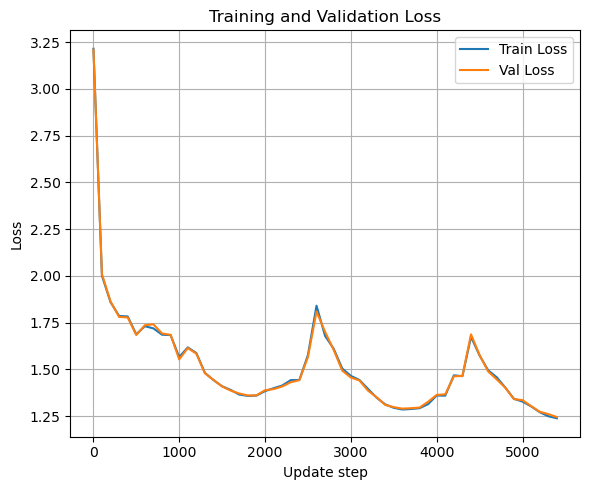

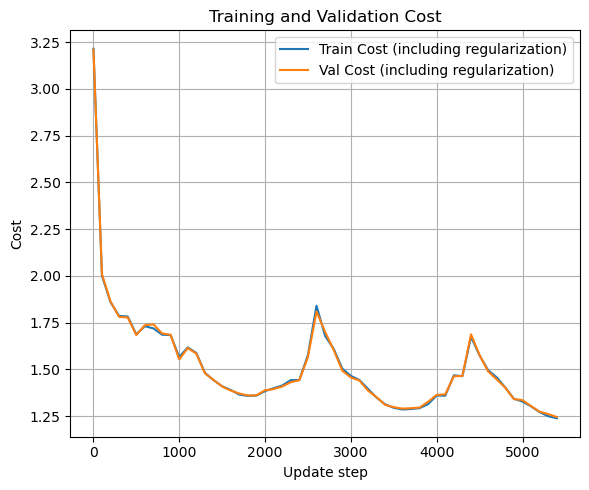

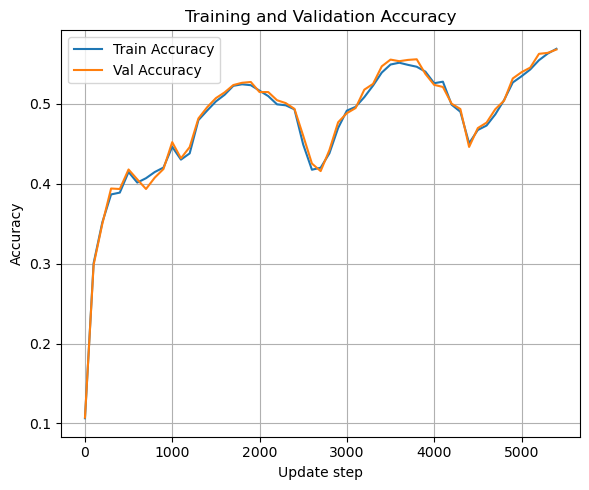

In [16]:
optimizer.plot_cyclical_lr_training_progress()

# Dropout
- without dropout and reg = 0.0: 0.5792 validation acc

In [8]:
from model_with_dropout import Model
model = Model(32*32*3, 400, 10, p =0.2)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=1e-3, reg=0.0, vertical_flip_prob=0.5, do_batch_translation=False)
n_batch = 100
N = X_train.shape[1]
n_s = int(2 * np.floor(N / n_batch))

In [9]:
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=n_s, n_cycles=3, batch_size=n_batch, print_every=500)

Update step 500 - Train Loss: 1.6286, Val Loss: 1.6692, Train Acc: 0.4351, Val Acc: 0.4194, LR: 0.055449
Update step 1000 - Train Loss: 1.5343, Val Loss: 1.5869, Train Acc: 0.4626, Val Acc: 0.4492, LR: 0.089001
Update step 1500 - Train Loss: 1.3106, Val Loss: 1.3804, Train Acc: 0.5418, Val Acc: 0.5226, LR: 0.033451
Update step 2000 - Train Loss: 1.2719, Val Loss: 1.3579, Train Acc: 0.5581, Val Acc: 0.5250, LR: 0.022119
Update step 2500 - Train Loss: 1.3941, Val Loss: 1.4779, Train Acc: 0.5123, Val Acc: 0.4924, LR: 0.077669
Update step 3000 - Train Loss: 1.3503, Val Loss: 1.4525, Train Acc: 0.5289, Val Acc: 0.4912, LR: 0.066781
Update step 3500 - Train Loss: 1.1542, Val Loss: 1.2771, Train Acc: 0.6030, Val Acc: 0.5588, LR: 0.011231
Update step 4000 - Train Loss: 1.1767, Val Loss: 1.3229, Train Acc: 0.5912, Val Acc: 0.5388, LR: 0.044339
Update step 4500 - Train Loss: 1.3694, Val Loss: 1.4990, Train Acc: 0.5203, Val Acc: 0.4812, LR: 0.099889
Update step 5000 - Train Loss: 1.1823, Val Loss

In [10]:
val_acc = optimizer.compute_accuracy(X_val, y_val)
test_acc = optimizer.compute_accuracy(X_test, y_test)
print("validation accuracy: ", val_acc)
print("test accuracy: ", test_acc)

validation accuracy:  0.5714
test accuracy:  0.5623


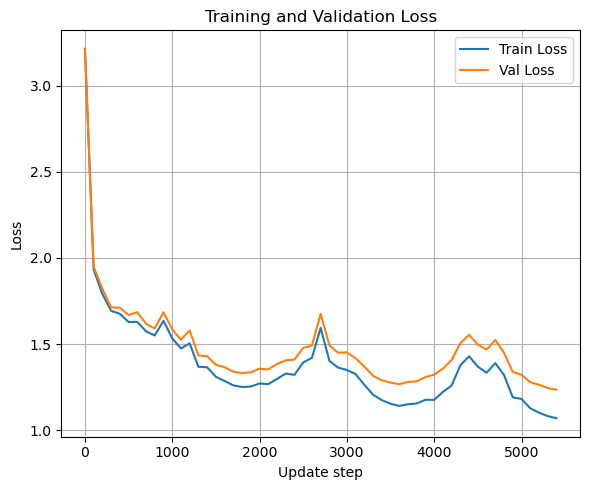

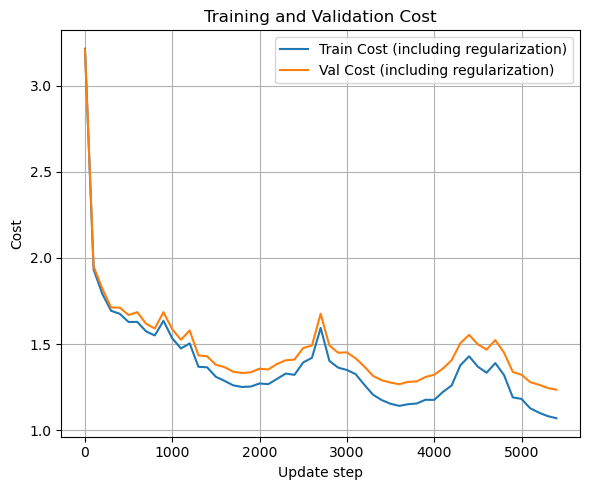

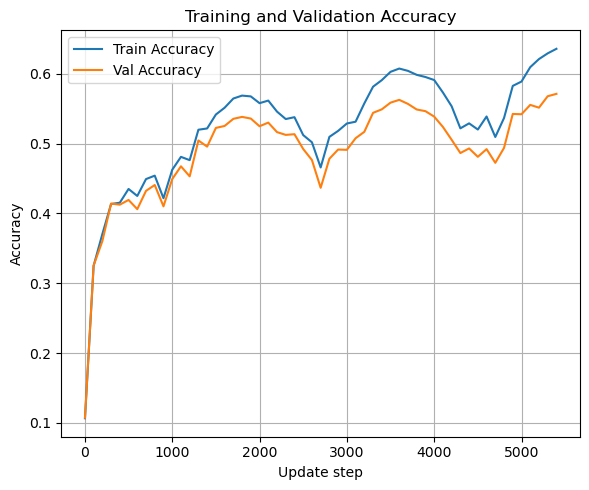

In [11]:
optimizer.plot_cyclical_lr_training_progress()

In [11]:
X_test, Y_test, y_test = load_batch("test_batch")
X, Y, y = load_batch("data_batch_1")
for i in range(2,6):
    X_temp, Y_temp, y_temp = load_batch(f"data_batch_{i}")
    X = np.concatenate((X, X_temp), axis=1)
    Y = np.concatenate((Y, Y_temp), axis=1)
    y = np.concatenate((y, y_temp))
# split into training and validation sets
X_train = X[:, :45000]
y_train = y[:45000]
X_val = X[:, 45000:]
y_val = y[45000:]
# scale data
scaler = Scaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

model = Model(32*32*3, 400, 10)
optimizer = ADAM(model, CrossEntropyLoss(), lr=1e-3, reg=0.0001, vertical_flip_prob=0.5)


In [12]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=200, batch_size=100, print_every=5)

Epoch 5/200 - Train Loss: 1.3143, Val Loss: 1.4524, Train Acc: 0.5425, Val Acc: 0.4978
Epoch 10/200 - Train Loss: 1.2583, Val Loss: 1.4445, Train Acc: 0.5627, Val Acc: 0.4998
Epoch 15/200 - Train Loss: 1.1785, Val Loss: 1.4143, Train Acc: 0.5929, Val Acc: 0.5172
Epoch 20/200 - Train Loss: 1.0846, Val Loss: 1.3665, Train Acc: 0.6222, Val Acc: 0.5406
Epoch 25/200 - Train Loss: 1.0224, Val Loss: 1.3288, Train Acc: 0.6446, Val Acc: 0.5506
Epoch 30/200 - Train Loss: 1.0256, Val Loss: 1.3650, Train Acc: 0.6448, Val Acc: 0.5464


KeyboardInterrupt: 

validation accuracy:  0.549
test accuracy:  0.5335


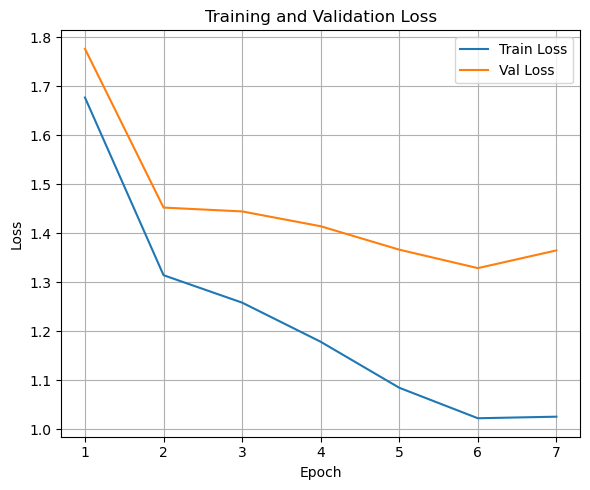

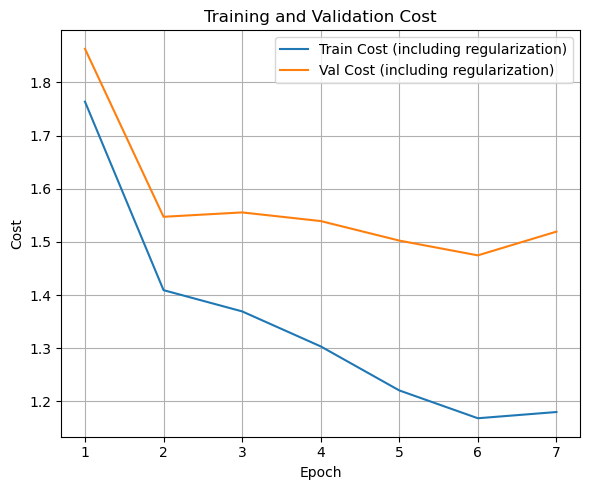

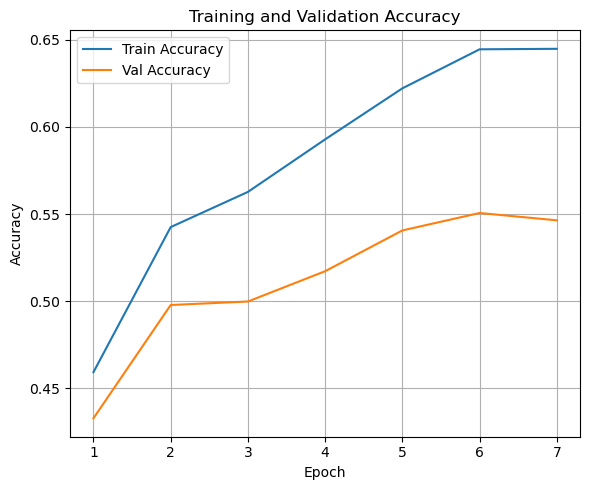

In [13]:
val_acc = optimizer.compute_accuracy(X_val, y_val)
test_acc = optimizer.compute_accuracy(X_test, y_test)
print("validation accuracy: ", val_acc)
print("test accuracy: ", test_acc)
optimizer.plot_training_progress()